In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt   
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import roc_auc_score,roc_curve,classification_report,confusion_matrix,plot_confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn import metrics,model_selection
from sklearn.preprocessing import scale

In [2]:
df=pd.read_csv("Holiday_Package.csv")

In [3]:
df.head()

,Unnamed: 0,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,1,no,48412,30,8,1,1,no
1,2,yes,37207,45,8,0,1,no
2,3,no,58022,46,9,0,0,no
3,4,no,66503,31,11,2,0,no
4,5,no,66734,44,12,0,2,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         872 non-null    int64 
 1   Holliday_Package   872 non-null    object
 2   Salary             872 non-null    int64 
 3   age                872 non-null    int64 
 4   educ               872 non-null    int64 
 5   no_young_children  872 non-null    int64 
 6   no_older_children  872 non-null    int64 
 7   foreign            872 non-null    object
dtypes: int64(6), object(2)
memory usage: 54.6+ KB


In [78]:
df.shape

(872, 6)

In [5]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [6]:
df.describe()

,Salary,age,educ,no_young_children,no_older_children
count,872.000000,872.000000,872.000000,872.000000,872.000000
mean,47729.172018,39.955275,9.307339,0.311927,0.982798
std,23418.668531,10.551675,3.036259,0.612870,1.086786
min,1322.000000,20.000000,1.000000,0.000000,0.000000
25%,35324.000000,32.000000,8.000000,0.000000,0.000000
50%,41903.500000,39.000000,9.000000,0.000000,1.000000
75%,53469.500000,48.000000,12.000000,0.000000,2.000000
max,236961.000000,62.000000,21.000000,3.000000,6.000000


In [7]:
df.isnull().sum()

Holliday_Package     0
Salary               0
age                  0
educ                 0
no_young_children    0
no_older_children    0
foreign              0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.Holliday_Package.value_counts(normalize=True)

no     0.540138
yes    0.459862
Name: Holliday_Package, dtype: float64

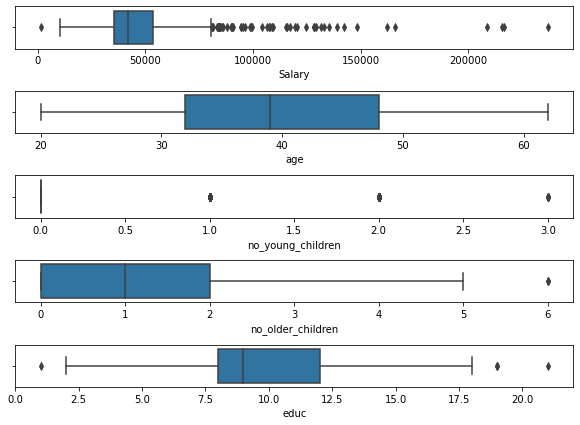

In [10]:
plt.figure(figsize=(10,7))
plt.subplot(5,1,1)
sns.boxplot(df["Salary"],orient="h")
plt.subplot(5,1,2)
sns.boxplot(df["age"],orient="h")
plt.subplot(5,1,3)
sns.boxplot(df["no_young_children"],orient="h")
plt.subplot(5,1,4)
sns.boxplot(df["no_older_children"],orient="h")
plt.subplot(5,1,5)
sns.boxplot(df["educ"],orient="h")
plt.subplots_adjust(hspace=1)


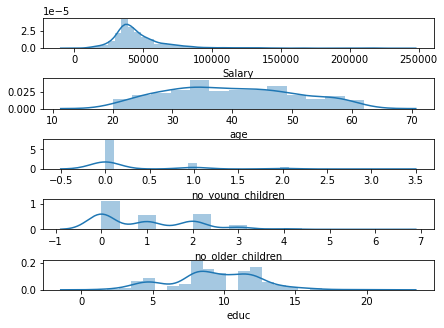

In [11]:
plt.figure(figsize=(7,5))
plt.subplot(5,1,1)
sns.distplot(df["Salary"],kde=True)
plt.subplot(5,1,2)
sns.distplot(df["age"],kde=True)
plt.subplot(5,1,3)
sns.distplot(df["no_young_children"],kde=True)
plt.subplot(5,1,4)
sns.distplot(df["no_older_children"],kde=True)
plt.subplot(5,1,5)
sns.distplot(df["educ"],kde=True)

plt.subplots_adjust(hspace=1)

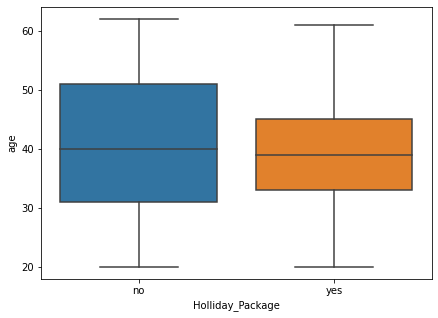

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(df.Holliday_Package,df.age)

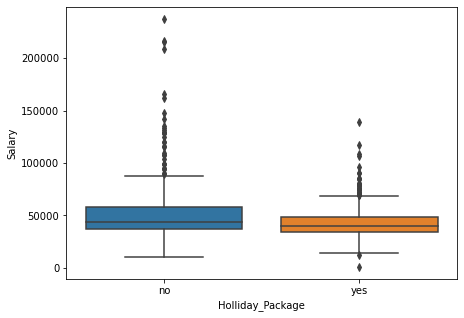

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(df.Holliday_Package,df.Salary)

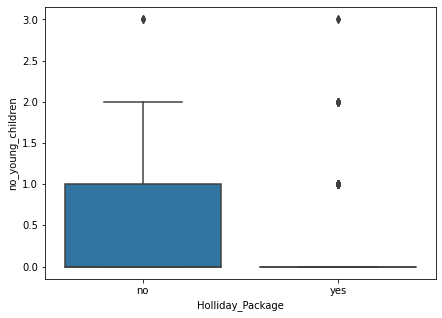

In [14]:
plt.figure(figsize=(7,5))
sns.boxplot(df.Holliday_Package,df.no_young_children)

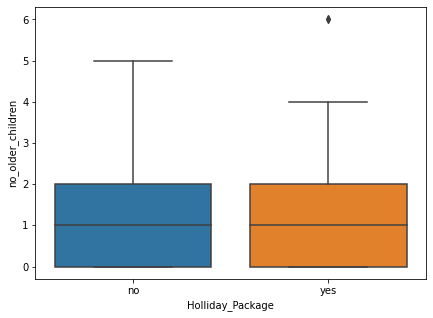

In [15]:
plt.figure(figsize=(7,5))
sns.boxplot(df.Holliday_Package,df.no_older_children)

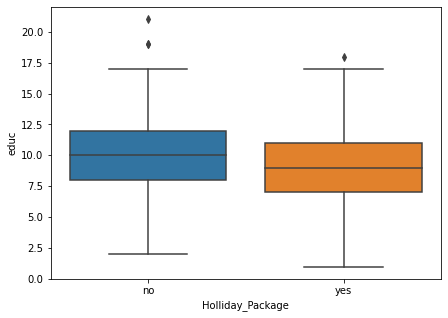

In [16]:
plt.figure(figsize=(7,5))
sns.boxplot(df.Holliday_Package,df.educ)

In [17]:
pd.crosstab(df.Holliday_Package,df.foreign,margins="All")

foreign,no,yes,All
Holliday_Package,,,
no,402,69,471
yes,254,147,401
All,656,216,872


In [18]:
def univariateAnalysis_category(cat_column):
    print("Details of " + cat_column)
    print("----------------------------------------------------------------")
    print(df_cat[cat_column].value_counts())
    print("       ")

In [19]:
df_cat = df.select_dtypes(include = ['object'])
lstcatcolumns = list(df_cat.columns.values)
lstcatcolumns

['Holliday_Package', 'foreign']

In [20]:
for x in lstcatcolumns:
    univariateAnalysis_category(x)

Details of Holliday_Package
----------------------------------------------------------------
no     471
yes    401
Name: Holliday_Package, dtype: int64
       
Details of foreign
----------------------------------------------------------------
no     656
yes    216
Name: foreign, dtype: int64
       


In [21]:
df_num = df.select_dtypes(include = ['float64', 'int64'])

In [22]:
corr = df_num.corr(method='pearson')

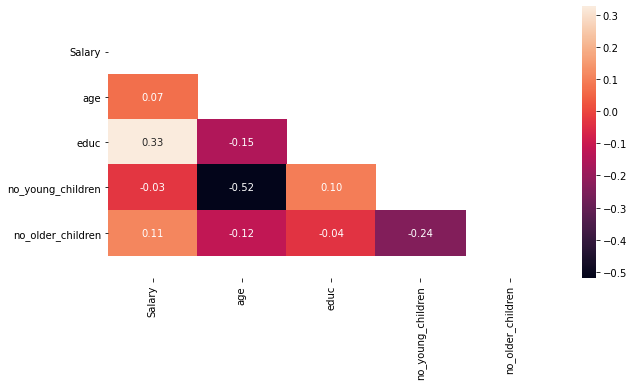

In [23]:
mask = np.triu(np.ones_like(corr, dtype=np.bool)) 
fig = plt.subplots(figsize=(10, 5))
ax=sns.heatmap(df_num.corr(), annot=True,fmt='.2f',mask=mask)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

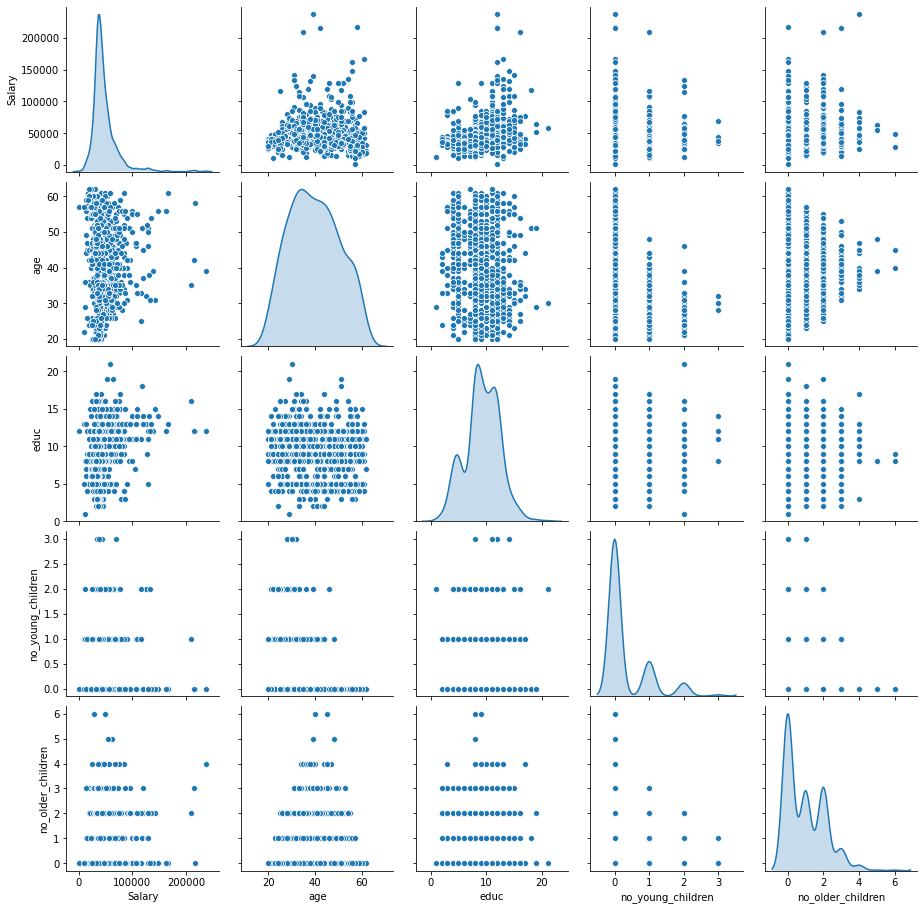

In [24]:
sns.pairplot(df_num, diag_kind = 'kde')

In [25]:
for feature in df.columns: 
    if df[feature].dtype == 'object':
        df[feature] = pd.Categorical(df[feature]).codes

In [26]:
df.head()

,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,0,48412,30,8,1,1,0
1,1,37207,45,8,0,1,0
2,0,58022,46,9,0,0,0
3,0,66503,31,11,2,0,0
4,0,66734,44,12,0,2,0


In [27]:
X_logistics= df.drop('Holliday_Package', axis=1)

# Copy target into the y dataframe. 
y_logistics= df[['Holliday_Package']]

In [28]:
from sklearn.model_selection import train_test_split
X_train_logistics, X_test_logistics, y_train_logistics, y_test_logistics = train_test_split(X_logistics, y_logistics, test_size=0.30 , random_state=1)

In [29]:
print("X_train data",X_train_logistics.shape)
print("X_test data",X_test_logistics.shape)
print("y_train data",y_train_logistics.shape)
print("y_test data",y_test_logistics.shape)


X_train data (610, 6)
X_test data (262, 6)
y_train data (610, 1)
y_test data (262, 1)


In [30]:
y_train_logistics.value_counts()

Holliday_Package
0                   326
1                   284
dtype: int64

In [31]:
y_test_logistics.value_counts()

Holliday_Package
0                   145
1                   117
dtype: int64

In [32]:
model = LogisticRegression(solver='newton-cg',max_iter=10000,penalty='none',verbose=True,n_jobs=2)
model.fit(X_train_logistics, y_train_logistics)

C:\Users\LAHI\AppData\Roaming\Python\Python38\site-packages\sklearn\utils\validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 out of   1 | elapsed:    4.9s finished


LogisticRegression(max_iter=10000, n_jobs=2, penalty='none', solver='newton-cg',
                   verbose=True)

In [33]:
ytrain_predict_logistics = model.predict(X_train_logistics)
ytest_predict_logistics = model.predict(X_test_logistics)

In [34]:
ytest_predict_prob_logistics=model.predict_proba(X_test_logistics)
pd.DataFrame(ytest_predict_prob_logistics).head()

,0,1
0,0.760399,0.239601
1,0.273260,0.726740
2,0.902624,0.097376
3,0.978140,0.021860
4,0.513226,0.486774


In [35]:
model.score(X_train_logistics, y_train_logistics)

0.6786885245901639

AUC: 0.743


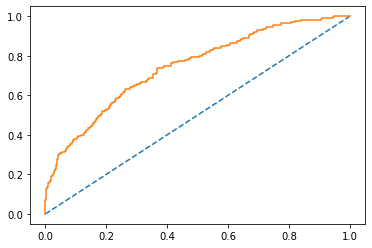

In [36]:
# predict probabilities
probs_logistics = model.predict_proba(X_train_logistics)
# keep probabilities for the positive outcome only
probs_logistics = probs_logistics[:, 1]
# calculate AUC
auc_logistics = roc_auc_score(y_train_logistics, probs_logistics)
print('AUC: %.3f' % auc_logistics)
# calculate roc curve
train_fpr_logistics, train_tpr_logistics, train_thresholds_logistics = roc_curve(y_train_logistics, probs_logistics)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr_logistics, train_tpr_logistics);

In [37]:
model.score(X_test_logistics, y_test_logistics)

0.6374045801526718

In [38]:
##AUC and ROC for the test data

AUC: 0.705


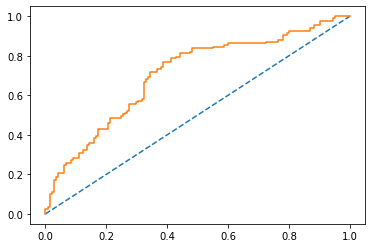

In [39]:
# predict probabilities
probs_logistics = model.predict_proba(X_test_logistics)
# keep probabilities for the positive outcome only
probs_logistics= probs_logistics[:, 1]
# calculate AUC
test_auc_logistics = roc_auc_score(y_test_logistics, probs_logistics)
print('AUC: %.3f' % test_auc_logistics)
# calculate roc curve
test_fpr_logistics, test_tpr_logistics, test_thresholds_logistics = roc_curve(y_test_logistics, probs_logistics)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(test_fpr_logistics, test_tpr_logistics);

In [40]:
##Confusion Matrix for the training data

In [41]:
confusion_matrix(y_train_logistics, ytrain_predict_logistics)

array([[252,  74],
       [122, 162]], dtype=int64)

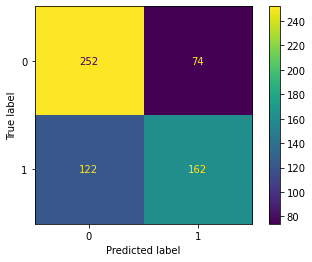

In [42]:
plot_confusion_matrix(model,X_train_logistics,y_train_logistics);

In [43]:
print(classification_report(y_train_logistics, ytrain_predict_logistics))

              precision    recall  f1-score   support

           0       0.67      0.77      0.72       326
           1       0.69      0.57      0.62       284

    accuracy                           0.68       610
   macro avg       0.68      0.67      0.67       610
weighted avg       0.68      0.68      0.67       610



In [44]:
##Confusion Matrix for test data

In [45]:
confusion_matrix(y_test_logistics, ytest_predict_logistics)

array([[102,  43],
       [ 52,  65]], dtype=int64)

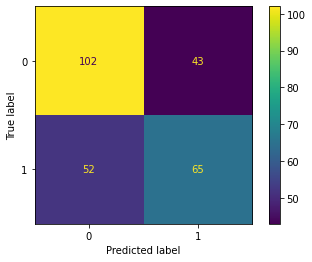

In [46]:
plot_confusion_matrix(model,X_test_logistics,y_test_logistics);

In [47]:
print(classification_report(y_test_logistics, ytest_predict_logistics))

              precision    recall  f1-score   support

           0       0.66      0.70      0.68       145
           1       0.60      0.56      0.58       117

    accuracy                           0.64       262
   macro avg       0.63      0.63      0.63       262
weighted avg       0.64      0.64      0.64       262



In [48]:
##Applying GridSearchCV for Logistic Regression

In [49]:
grid_logistics={'penalty':['l2','none'],
      'solver':['sag','lbfgs'],
      'tol':[0.0001,0.00001]}

In [50]:
model = LogisticRegression(max_iter=10000,n_jobs=2)

In [51]:
grid_search_logistics= GridSearchCV(estimator = model, param_grid = grid_logistics, cv = 3,n_jobs=-1,scoring='f1')

In [52]:
grid_search_logistics.fit(X_train_logistics, y_train_logistics)

C:\Users\LAHI\AppData\Roaming\Python\Python38\site-packages\sklearn\utils\validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=10000, n_jobs=2),
             n_jobs=-1,
             param_grid={'penalty': ['l2', 'none'], 'solver': ['sag', 'lbfgs'],
                         'tol': [0.0001, 1e-05]},
             scoring='f1')

In [53]:
print(grid_search_logistics.best_params_,'\n')
print(grid_search_logistics.best_estimator_)

{'penalty': 'l2', 'solver': 'lbfgs', 'tol': 0.0001} 

LogisticRegression(max_iter=10000, n_jobs=2)


In [54]:
best_model_logistics = grid_search_logistics.best_estimator_

In [55]:
# Prediction on the training set

ytrain_predict_logistics = best_model_logistics.predict(X_train_logistics)
ytest_predict_logistics = best_model_logistics.predict(X_test_logistics)

In [56]:
## Getting the probabilities on the test set

ytest_predict_prob_logistics=best_model_logistics.predict_proba(X_test_logistics)
pd.DataFrame(ytest_predict_prob_logistics).head()

,0,1
0,0.628400,0.371600
1,0.517955,0.482045
2,0.559374,0.440626
3,0.728628,0.271372
4,0.504930,0.495070


              precision    recall  f1-score   support

           0       0.53      0.90      0.67       326
           1       0.42      0.08      0.14       284

    accuracy                           0.52       610
   macro avg       0.47      0.49      0.40       610
weighted avg       0.48      0.52      0.42       610
 



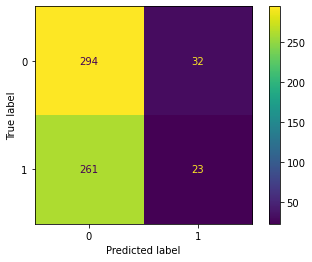

In [57]:
## Confusion matrix on the training data

plot_confusion_matrix(best_model_logistics,X_train_logistics,y_train_logistics)
print(classification_report(y_train_logistics, ytrain_predict_logistics),'\n');

              precision    recall  f1-score   support

           0       0.55      0.89      0.68       145
           1       0.38      0.09      0.14       117

    accuracy                           0.53       262
   macro avg       0.47      0.49      0.41       262
weighted avg       0.47      0.53      0.44       262
 



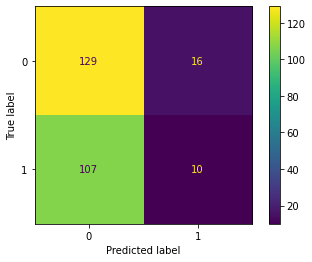

In [58]:
## Confusion matrix on the test data

plot_confusion_matrix(best_model_logistics,X_test_logistics,y_test_logistics)
print(classification_report(y_test_logistics, ytest_predict_logistics),'\n');

In [59]:
X_LDA= df.drop('Holliday_Package',axis=1)
Y_LDA = df.pop('Holliday_Package')

In [60]:
X_train_LDA,X_test_LDA,Y_train_LDA,Y_test_LDA = model_selection.train_test_split(X_LDA,Y_LDA,test_size=0.30,random_state=1,stratify = Y_LDA)


In [61]:
print('Number of rows and columns of the training set for the independent variables:',X_train_LDA.shape)
print('Number of rows and columns of the training set for the dependent variable:',Y_train_LDA.shape)
print('Number of rows and columns of the test set for the independent variables:',X_test_LDA.shape)
print('Number of rows and columns of the test set for the dependent variable:',Y_test_LDA.shape)

Number of rows and columns of the training set for the independent variables: (610, 6)
Number of rows and columns of the training set for the dependent variable: (610,)
Number of rows and columns of the test set for the independent variables: (262, 6)
Number of rows and columns of the test set for the dependent variable: (262,)


In [62]:
#Build LDA Model
clf = LinearDiscriminantAnalysis()
model_LDA=clf.fit(X_train_LDA,Y_train_LDA)

In [63]:
## Prediction

In [64]:
# Training Data Class Prediction with a cut-off value of 0.5
pred_class_train_LDA = model_LDA.predict(X_train_LDA)

# Test Data Class Prediction with a cut-off value of 0.5
pred_class_test_LDA = model_LDA.predict(X_test_LDA)

In [65]:
##Training Data and Test Data Confusion Matrix Comparison

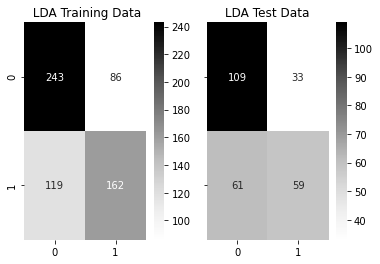

In [66]:
f,a =  plt.subplots(1,2,sharex=True,sharey=True,squeeze=False)

#Plotting confusion matrix for the different models for the Training Data

plot_0 = sns.heatmap((metrics.confusion_matrix(Y_train_LDA,pred_class_train_LDA)),annot=True,fmt='.5g',cmap='Greys',ax=a[0][0]);
a[0][0].set_title(' LDA Training Data')

plot_1 = sns.heatmap((metrics.confusion_matrix(Y_test_LDA,pred_class_test_LDA)),annot=True,fmt='.5g',cmap='Greys',ax=a[0][1]);
a[0][1].set_title('LDA Test Data');

In [67]:
##Training Data and Test Data Classification Report Comparison

In [68]:
print('Classification Report of the LDA training data:\n\n',metrics.classification_report(Y_train_LDA,pred_class_train_LDA),'\n')
print('Classification Report of the LDA test data:\n\n',metrics.classification_report(Y_test_LDA,pred_class_test_LDA),'\n')

Classification Report of the LDA training data:

               precision    recall  f1-score   support

           0       0.67      0.74      0.70       329
           1       0.65      0.58      0.61       281

    accuracy                           0.66       610
   macro avg       0.66      0.66      0.66       610
weighted avg       0.66      0.66      0.66       610
 

Classification Report of the LDA test data:

               precision    recall  f1-score   support

           0       0.64      0.77      0.70       142
           1       0.64      0.49      0.56       120

    accuracy                           0.64       262
   macro avg       0.64      0.63      0.63       262
weighted avg       0.64      0.64      0.63       262
 



In [69]:
##Probability prediction for the training and test data

In [70]:
# Training Data Probability Prediction
pred_prob_train_LDA = model_LDA.predict_proba(X_train_LDA)

# Test Data Probability Prediction
pred_prob_test_LDA = model_LDA.predict_proba(X_test_LDA)

In [71]:
pred_prob_train_LDA[:,1]

array([0.7381512 , 0.28961707, 0.38234291, 0.76483486, 0.46682945,
       0.44346246, 0.37680169, 0.30948321, 0.61081614, 0.64208316,
       0.25213217, 0.26469615, 0.39923017, 0.04631524, 0.23022974,
       0.36249565, 0.53701148, 0.33367574, 0.63047975, 0.62551868,
       0.62038047, 0.26045898, 0.8778445 , 0.33010529, 0.09907975,
       0.83197262, 0.20726445, 0.7448485 , 0.52475576, 0.18602064,
       0.34007289, 0.32707499, 0.37873484, 0.42874061, 0.31084381,
       0.28746402, 0.11553843, 0.53094637, 0.47040748, 0.22122639,
       0.26026817, 0.80975365, 0.51459465, 0.74029285, 0.79737631,
       0.40099878, 0.298335  , 0.93065406, 0.44451279, 0.70660174,
       0.75490574, 0.46875931, 0.77220783, 0.37565531, 0.22661608,
       0.74188557, 0.26237721, 0.5247693 , 0.6721239 , 0.34088095,
       0.62335813, 0.57741879, 0.54295979, 0.45085985, 0.56389786,
       0.5965561 , 0.12149134, 0.57410954, 0.3890238 , 0.26157228,
       0.35655665, 0.7429183 , 0.76617151, 0.22742495, 0.42898

LDA AUC for the Training Data: 0.733
LDA AUC for the Test Data: 0.714


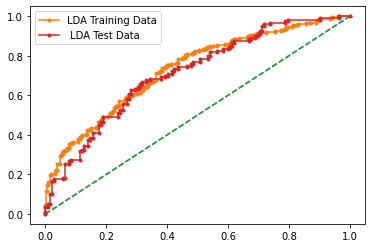

In [72]:
# LDA AUC and ROC for the training data

# calculate AUC
auc_train_LDA = metrics.roc_auc_score(Y_train_LDA,pred_prob_train_LDA[:,1])
print('LDA AUC for the Training Data: %.3f' % auc_train_LDA)

#  calculate roc curve
fpr_train_LDA, tpr_train_LDA, thresholds_train_LDA = metrics.roc_curve(Y_train_LDA,pred_prob_train_LDA[:,1])
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr_train_LDA, tpr_train_LDA, marker='.',label = 'LDA Training Data')


# LDA AUC and ROC for the test data

# calculate AUC
auc_test_LDA = metrics.roc_auc_score(Y_test_LDA,pred_prob_test_LDA[:,1])
print('LDA AUC for the Test Data: %.3f' % auc_test_LDA)

#  calculate roc curve
fpr_test_LDA, tpr_test_LDA, thresholds_test_LDA = metrics.roc_curve(Y_test_LDA,pred_prob_test_LDA[:,1])
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr_test_LDA, tpr_test_LDA, marker='.',label=' LDA Test Data')
# show the plot
plt.legend(loc='best')
plt.show()

0.1 

Accuracy Score 0.482
F1 Score 0.6393 

Confusion Matrix


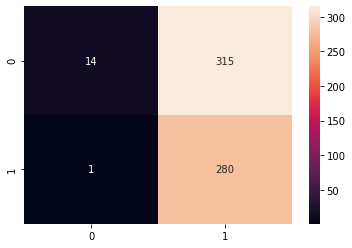

0.2 

Accuracy Score 0.5213
F1 Score 0.6499 

Confusion Matrix


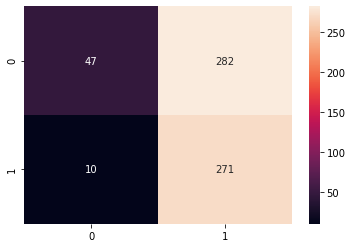

0.3 

Accuracy Score 0.5934
F1 Score 0.6693 

Confusion Matrix


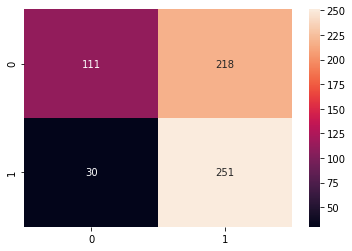

0.4 

Accuracy Score 0.6656
F1 Score 0.6762 

Confusion Matrix


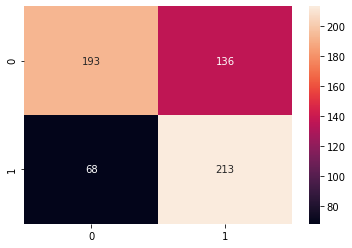

0.5 

Accuracy Score 0.6639
F1 Score 0.6125 

Confusion Matrix


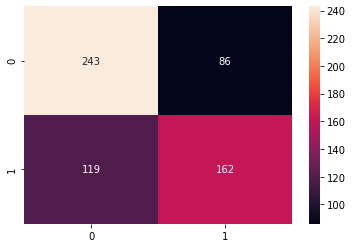

0.6 

Accuracy Score 0.659
F1 Score 0.5336 

Confusion Matrix


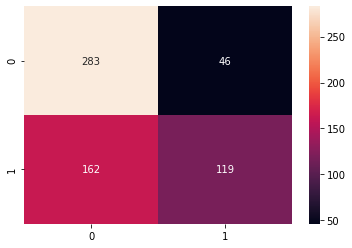

0.7 

Accuracy Score 0.6492
F1 Score 0.4398 

Confusion Matrix


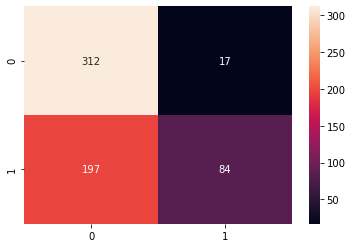

0.8 

Accuracy Score 0.5885
F1 Score 0.1981 

Confusion Matrix


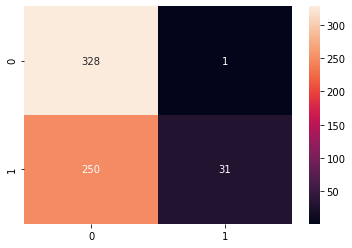

0.9 

Accuracy Score 0.5426
F1 Score 0.0141 

Confusion Matrix


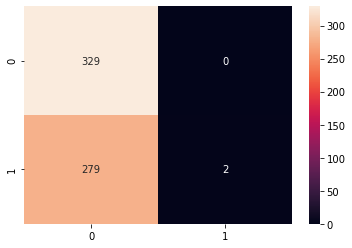

In [73]:
for j in np.arange(0.1,1,0.1):
    custom_prob = j #defining the cut-off value of our choice
    custom_cutoff_data=[]#defining an empty list
    for i in range(0,len(Y_train_LDA)):#defining a loop for the length of the test data
        if np.array(pred_prob_train_LDA[:,1])[i] > custom_prob:#issuing a condition for our probability values to be 
            #greater than the custom cutoff value
            a=1#if the probability values are greater than the custom cutoff then the value should be 1
        else:
            a=0#if the probability values are less than the custom cutoff then the value should be 0
        custom_cutoff_data.append(a)#adding either 1 or 0 based on the condition to the end of the list defined by us
    print(round(j,3),'\n')
    print('Accuracy Score',round(metrics.accuracy_score(Y_train_LDA,custom_cutoff_data),4))
    print('F1 Score',round(metrics.f1_score(Y_train_LDA,custom_cutoff_data),4),'\n')
    plt.figure(figsize=(6,4))
    print('Confusion Matrix')
    sns.heatmap(metrics.confusion_matrix(Y_train_LDA,custom_cutoff_data),annot=True,fmt='.4g'),'\n\n'
    plt.show();

In [74]:
#Predicting the classes on the test data

data_pred_custom_cutoff=[]
for i in range(0,len(pred_prob_test_LDA[:,1])):
    if np.array(pred_prob_test_LDA[:,1])[i]>0.2:
        a=1
    else:
        a=0
    data_pred_custom_cutoff.append(a)

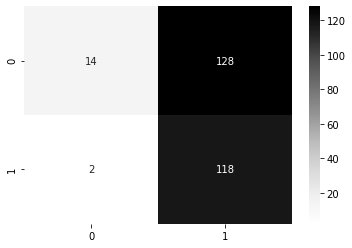

In [75]:
sns.heatmap((metrics.confusion_matrix(Y_test_LDA,data_pred_custom_cutoff)),annot=True,fmt='.5g',cmap='Greys');


In [76]:
print('Classification Report of the default cut-off test data:\n\n',metrics.classification_report(Y_test_LDA,pred_class_test_LDA),'\n\n\n')
print('Classification Report of the custom cut-off test data:\n\n',metrics.classification_report(Y_test_LDA,data_pred_custom_cutoff),'\n')

Classification Report of the default cut-off test data:

               precision    recall  f1-score   support

           0       0.64      0.77      0.70       142
           1       0.64      0.49      0.56       120

    accuracy                           0.64       262
   macro avg       0.64      0.63      0.63       262
weighted avg       0.64      0.64      0.63       262
 



Classification Report of the custom cut-off test data:

               precision    recall  f1-score   support

           0       0.88      0.10      0.18       142
           1       0.48      0.98      0.64       120

    accuracy                           0.50       262
   macro avg       0.68      0.54      0.41       262
weighted avg       0.69      0.50      0.39       262
 



In [79]:
sd=pd.read_csv("Holiday_Package.csv")

In [80]:
sd.head()

,Unnamed: 0,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,1,no,48412,30,8,1,1,no
1,2,yes,37207,45,8,0,1,no
2,3,no,58022,46,9,0,0,no
3,4,no,66503,31,11,2,0,no
4,5,no,66734,44,12,0,2,no


In [81]:
sd.drop("Unnamed: 0",axis=1,inplace=True)

In [82]:
for feature in sd.columns: 
    if sd[feature].dtype == 'object':
        sd[feature] = pd.Categorical(sd[feature]).codes

In [85]:
A_logistics= sd.drop('Holliday_Package', axis=1)

# Copy target into the y dataframe. 
B_logistics= sd[['Holliday_Package']]

In [86]:
from sklearn.model_selection import train_test_split
A_train_logistics, A_test_logistics, B_train_logistics, B_test_logistics = train_test_split(A_logistics, B_logistics, test_size=0.30 , random_state=12)

In [87]:
model_A= LogisticRegression()
model_A.fit(A_train_logistics, B_train_logistics)

C:\Users\LAHI\AppData\Roaming\Python\Python38\site-packages\sklearn\utils\validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


LogisticRegression()

In [89]:
for idx, col_name in enumerate(A_logistics.columns):
    print("The coefficient for {} is {}".format(col_name, model_A.coef_[0][idx]))

The coefficient for Salary is -1.883926099476721e-05
The coefficient for age is -0.0022008071498029833
The coefficient for educ is 0.07421021190430613
The coefficient for no_young_children is -0.06966101499720827
The coefficient for no_older_children is 0.10407146393307927
The coefficient for foreign is 0.06493718752754128
